## Feature Engineering & Cleaning
Goal: Transform raw 50-column clinical data into ML-ready features

### Imports & Load

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("diabetic_data.csv")
df.replace("?", np.nan, inplace=True)
print("Loaded shape:", df.shape)

Loaded shape: (101766, 50)


### Drop useless columns

In [12]:
# Drop columns with too many missing values or no predictive value
cols_to_drop = [
    "weight",  # 97% missing
    "max_glu_serum",  # 95% missing
    "A1Cresult",  # 83% missing
    "medical_specialty",  # 49% missing
    "payer_code",  # 40% missing
    "encounter_id",  # just an ID
    "patient_nbr",  # just an ID
]

df.drop(columns=cols_to_drop, inplace=True)
print("Shape after dropping:", df.shape)
print("Remaining columns:", df.columns.tolist())

Shape after dropping: (101766, 43)
Remaining columns: ['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


###  Handle remaining missing values

In [13]:
for col in ["race", "diag_1", "diag_2", "diag_3"]:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after fix:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nNo missing values!" if df.isnull().sum().sum() == 0 else "Still has missing!")

Missing values after fix:
Series([], dtype: int64)

No missing values!


### Create target variable

In [14]:
# Binary target: 1 = readmitted within 30 days (high risk), 0 = everything else
df["high_risk"] = (df["readmitted"] == "<30").astype(int)
df.drop(columns=["readmitted"], inplace=True)

print("Target distribution:")
print(df["high_risk"].value_counts())
print(
    f"\nClass imbalance ratio: {df['high_risk'].value_counts()[0] / df['high_risk'].value_counts()[1]:.1f}:1"
)

Target distribution:
high_risk
0    90409
1    11357
Name: count, dtype: int64

Class imbalance ratio: 8.0:1


### Encode age as ordered numeric

In [15]:
age_mapping = {
    "[0-10)": 5,
    "[10-20)": 15,
    "[20-30)": 25,
    "[30-40)": 35,
    "[40-50)": 45,
    "[50-60)": 55,
    "[60-70)": 65,
    "[70-80)": 75,
    "[80-90)": 85,
    "[90-100)": 95,
}
df["age"] = df["age"].map(age_mapping)
print("Age encoded sample:")
print(df["age"].value_counts().sort_index())

Age encoded sample:
age
5       161
15      691
25     1657
35     3775
45     9685
55    17256
65    22483
75    26068
85    17197
95     2793
Name: count, dtype: int64


### Encode medication change columns

In [16]:
# These columns have values like: 'No', 'Up', 'Down', 'Steady'
# Encode: No=0, any change=1
change_cols = [
    "metformin",
    "repaglinide",
    "nateglinide",
    "chlorpropamide",
    "glimepiride",
    "acetohexamide",
    "glipizide",
    "glyburide",
    "tolbutamide",
    "pioglitazone",
    "rosiglitazone",
    "acarbose",
    "miglitol",
    "troglitazone",
    "tolazamide",
    "examide",
    "citoglipton",
    "insulin",
    "glyburide-metformin",
    "glipizide-metformin",
    "glimepiride-pioglitazone",
    "metformin-rosiglitazone",
    "metformin-pioglitazone",
]

for col in change_cols:
    if col in df.columns:
        df[col] = df[col].apply(lambda x: 0 if x == "No" else 1)

print("Medication columns encoded!")
print(df[change_cols[:5]].head())

Medication columns encoded!
   metformin  repaglinide  nateglinide  chlorpropamide  glimepiride
0          0            0            0               0            0
1          0            0            0               0            0
2          0            0            0               0            0
3          0            0            0               0            0
4          0            0            0               0            0


### Simplify diagnosis codes 

In [17]:
# Simplify ICD-9 diagnosis codes into categories
def simplify_diag(code):
    try:
        code = str(code)
        if code.startswith("V") or code.startswith("E"):
            return "Other"
        code_num = float(code)
        if 390 <= code_num <= 459 or code_num == 785:
            return "Circulatory"
        elif 460 <= code_num <= 519 or code_num == 786:
            return "Respiratory"
        elif 520 <= code_num <= 579 or code_num == 787:
            return "Digestive"
        elif code_num == 250:
            return "Diabetes"
        elif 800 <= code_num <= 999:
            return "Injury"
        elif 710 <= code_num <= 739:
            return "Musculoskeletal"
        elif 580 <= code_num <= 629 or code_num == 788:
            return "Genitourinary"
        elif 140 <= code_num <= 239:
            return "Neoplasms"
        else:
            return "Other"
    except:
        return "Other"


df["diag_1"] = df["diag_1"].apply(simplify_diag)
df["diag_2"] = df["diag_2"].apply(simplify_diag)
df["diag_3"] = df["diag_3"].apply(simplify_diag)

print("Diagnosis categories:")
print(df["diag_1"].value_counts())

Diagnosis categories:
diag_1
Circulatory        30458
Other              26694
Respiratory        14423
Digestive           9475
Injury              6974
Genitourinary       5117
Musculoskeletal     4957
Neoplasms           3433
Diabetes             235
Name: count, dtype: int64


### Encode binary & categorical columns

In [18]:
# Binary columns
df["change"] = (df["change"] == "Ch").astype(int)
df["diabetesMed"] = (df["diabetesMed"] == "Yes").astype(int)
df["gender"] = (df["gender"] == "Male").astype(int)

# One-hot encode remaining categoricals
cat_cols = ["race", "diag_1", "diag_2", "diag_3"]
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print("Shape after encoding:", df.shape)
print("All numeric now:", df.select_dtypes(include="object").shape[1] == 0)

Shape after encoding: (101766, 67)
All numeric now: True


###  Save ML-ready dataset

In [19]:
df.to_csv("diabetic_ml_ready.csv", index=False)
print("Saved diabetic_ml_ready.csv")
print("Final shape:", df.shape)
print("\nTarget balance:")
print(df["high_risk"].value_counts())

Saved diabetic_ml_ready.csv
Final shape: (101766, 67)

Target balance:
high_risk
0    90409
1    11357
Name: count, dtype: int64


### Feature count visualization

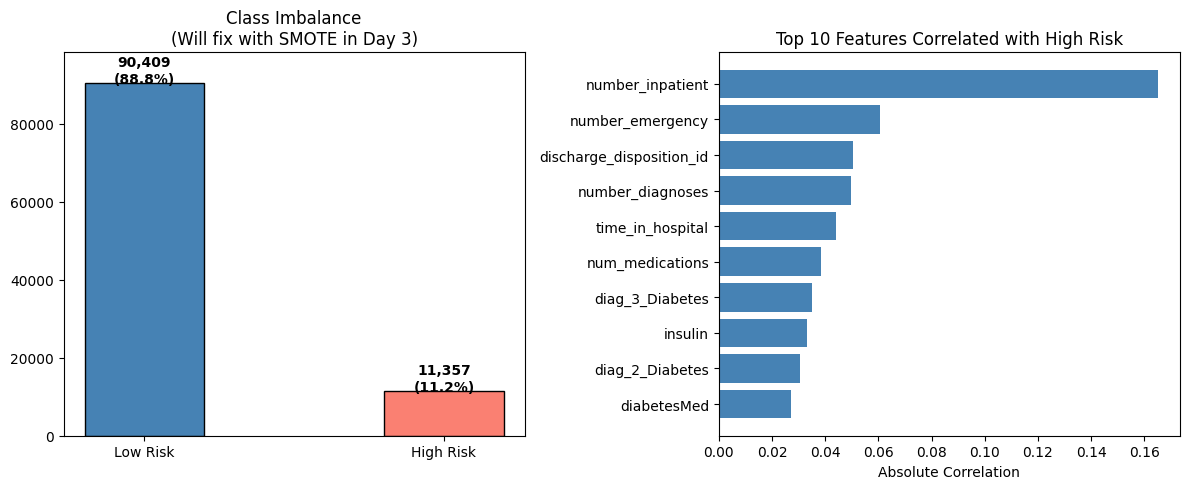

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Class imbalance
counts = df["high_risk"].value_counts().sort_index()
bars = axes[0].bar(
    ["Low Risk", "High Risk"],
    counts.values,
    color=["steelblue", "salmon"],
    edgecolor="black",
    width=0.4,
)
for bar, count in zip(bars, counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f"{count:,}\n({count/len(df)*100:.1f}%)",
        ha="center",
        fontweight="bold",
    )
axes[0].set_title("Class Imbalance\n(Will fix with SMOTE in Day 3)")
axes[0].set_ylim(0, max(counts.values) + 8000)

# Top correlated features with target
correlations = (
    df.corr()["high_risk"].drop("high_risk").abs().sort_values(ascending=False).head(10)
)
axes[1].barh(correlations.index[::-1], correlations.values[::-1], color="steelblue")
axes[1].set_title("Top 10 Features Correlated with High Risk")
axes[1].set_xlabel("Absolute Correlation")

plt.tight_layout()
plt.savefig("images/feature_engineering.png")
plt.show()

## Day 2 Summary
- Dropped 7 columns (high missing % or IDs)
- Replaced '?' with NaN, imputed remaining with mode
- Simplified 700+ ICD-9 diagnosis codes into 8 meaningful categories
- Encoded all categorical columns — age as ordered numeric
- Encoded 23 medication columns as binary (changed/not changed)
- Final shape: ~101K rows × 67 columns
- Key challenge: 8.8:1 class imbalance — will handle with SMOTE